In [5]:
import urllib.request

# This downloads a public domain photo of a crowd
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/basketball2.png"
urllib.request.urlretrieve(url, "people.jpg")

print("Successfully downloaded 'people.jpg'! You can now run the detection.")

Successfully downloaded 'people.jpg'! You can now run the detection.


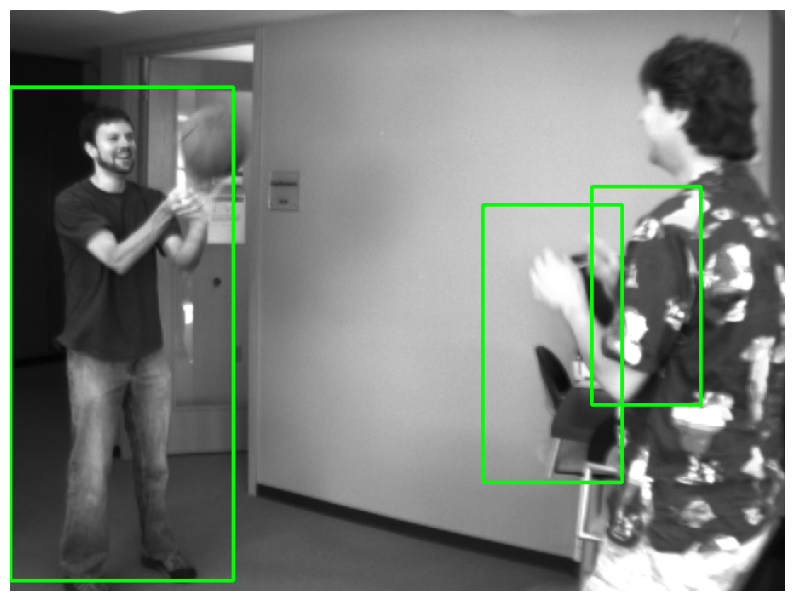

Found 3 people.


In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. THE FIX: Change 'image.jpg' to your ACTUAL filename (e.g., 'person.png')
filename = 'people.jpg' 

# Check if the file actually exists before trying to read it
if not os.path.exists(filename):
    print(f"ERROR: The file '{filename}' was not found in this folder!")
else:
    # 2. LOAD THE IMAGE
    img = cv2.imread(filename)
    
    # 3. SETUP DETECTION
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    # Convert to Gray
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 4. DETECTION
    (rects, weights) = hog.detectMultiScale(img_gray, winStride=(4, 4), padding=(8, 8), scale=1.05)

    # 5. DRAWING
    for (x, y, w, h) in rects:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # 6. DISPLAY
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    print(f"Found {len(rects)} people.")

In [1]:
import cv2

# 1. Initialize the Camera and the Detector
cap = cv2.VideoCapture(0) # '0' is usually the default webcam
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

print("Press 'q' on your keyboard to stop the camera!")

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        break

    # 2. Detection Logic (runs on every frame)
    # We resize the frame slightly to make it run faster
    frame = cv2.resize(frame, (640, 480))
    (rects, weights) = hog.detectMultiScale(frame, winStride=(8, 8), padding=(8, 8), scale=1.03)

    # 3. Drawing Logic
    for (x, y, w, h) in rects:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, "Human", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 4. Display the resulting frame
    cv2.imshow('Live Human Detection', frame)

    # Stop the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
cv2.destroyAllWindows()

Press 'q' on your keyboard to stop the camera!


KeyboardInterrupt: 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/sushanth/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /Users/sushanth/Documents/hacka/people.jpg: 480x640 2 persons, 61.7ms
Speed: 1.7ms preprocess, 61.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


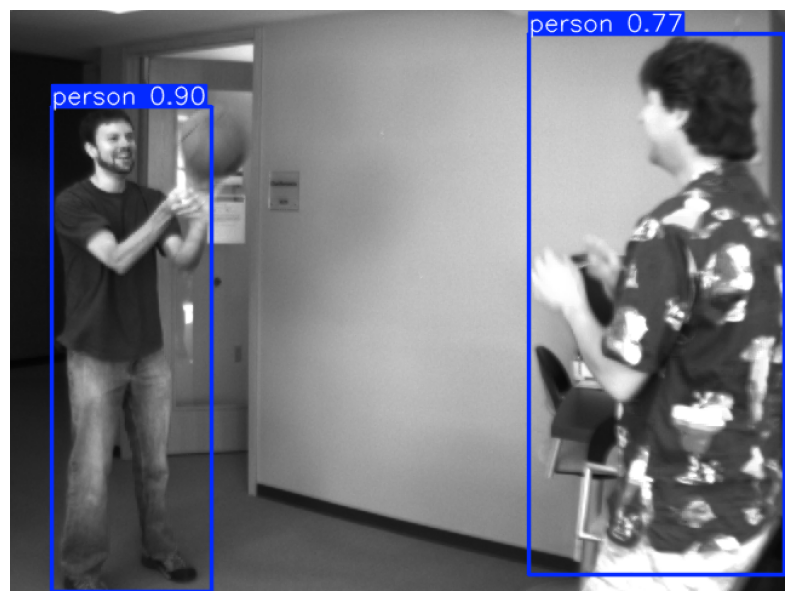

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load a pre-trained model (YOLOv8 is fast and very accurate)
model = YOLO('yolov8n.pt') 

# 2. Run detection (it automatically handles resizing and color)
# conf=0.5 means "only show me things you are 50% sure about"
results = model('people.jpg', conf=0.5)

# 3. Use YOLO's built-in plotting to see the results
res_plotted = results[0].plot()

# 4. Display
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [1]:
import cv2
from ultralytics import YOLO

# 1. Setup
model = YOLO('yolov8n.pt')
cap = cv2.VideoCapture(0)

# 2. Stability Variables
stable_count = 0      # The count we are "sure" about
candidate_count = 0   # The new count we are currently testing
counter = 0           # How many frames the candidate has been consistent
STABILITY_THRESHOLD = 10  # Number of frames to wait (approx 0.3 seconds)

print(f"Monitoring started. Stability filter set to {STABILITY_THRESHOLD} frames.")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 3. Silent Detection
    results = model(frame, stream=False, classes=[0], verbose=False)
    current_seen = len(results[0].boxes)

    # 4. THE STABILITY FILTER LOGIC
    if current_seen == stable_count:
        # Everything is the same, reset the "testing" counter
        counter = 0
        candidate_count = current_seen
    else:
        # We see a potential change! 
        if current_seen == candidate_count:
            counter += 1 # It's consistent with the last frame
        else:
            candidate_count = current_seen # It's a brand new number, start over
            counter = 0

    # 5. COMMIT THE LOG (Only after passing the threshold)
    if counter >= STABILITY_THRESHOLD:
        if candidate_count > stable_count:
            print(f" [+] CONFIRMED: Person entered. Total: {candidate_count}")
        elif candidate_count < stable_count:
            print(f" [-] CONFIRMED: Person left. Total: {candidate_count}")
        
        stable_count = candidate_count
        counter = 0 # Reset after logging

    # 6. Visual Output
    annotated_frame = results[0].plot()
    cv2.imshow("Filtered Human Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Monitoring started. Stability filter set to 10 frames.
 [+] CONFIRMED: Person entered. Total: 1
 [+] CONFIRMED: Person entered. Total: 2
 [-] CONFIRMED: Person left. Total: 1
 [-] CONFIRMED: Person left. Total: 0
 [+] CONFIRMED: Person entered. Total: 1
 [+] CONFIRMED: Person entered. Total: 2
 [-] CONFIRMED: Person left. Total: 1


KeyboardInterrupt: 

In [1]:
import cv2
from ultralytics import YOLO

# 1. Setup
model = YOLO('yolov8n.pt')
cap = cv2.VideoCapture(0)

# 2. Stability Variables
stable_count = 0      # The count we are "sure" about
candidate_count = 0   # The new count we are currently testing
counter = 0           # How many frames the candidate has been consistent
STABILITY_THRESHOLD = 10  # Number of frames to wait (approx 0.3 seconds)

print(f"Monitoring started. Stability filter set to {STABILITY_THRESHOLD} frames.")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 3. Silent Detection
    results = model(frame, stream=False, classes=[0], verbose=False)
    current_seen = len(results[0].boxes)

    # 4. THE STABILITY FILTER LOGIC
    if current_seen == stable_count:
        # Everything is the same, reset the "testing" counter
        counter = 0
        candidate_count = current_seen
    else:
        # We see a potential change! 
        if current_seen == candidate_count:
            counter += 1 # It's consistent with the last frame
        else:
            candidate_count = current_seen # It's a brand new number, start over
            counter = 0

    # 5. COMMIT THE LOG (Only after passing the threshold)
    if counter >= STABILITY_THRESHOLD:
        if candidate_count > stable_count:
            print(f" [+] CONFIRMED: Person entered. Total: {candidate_count}")
        elif candidate_count < stable_count:
            print(f" [-] CONFIRMED: Person left. Total: {candidate_count}")
        
        stable_count = candidate_count
        counter = 0 # Reset after logging

    # 6. Visual Output
    annotated_frame = results[0].plot()
    cv2.imshow("Filtered Human Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Monitoring started. Stability filter set to 10 frames.
 [+] CONFIRMED: Person entered. Total: 1
 [+] CONFIRMED: Person entered. Total: 2
 [-] CONFIRMED: Person left. Total: 1
 [-] CONFIRMED: Person left. Total: 0
 [+] CONFIRMED: Person entered. Total: 1
 [+] CONFIRMED: Person entered. Total: 2
 [-] CONFIRMED: Person left. Total: 1


KeyboardInterrupt: 

In [ ]:
import cv2
from ultralytics import YOLO

# 1. Setup
model = YOLO('yolov8n.pt')
cap = cv2.VideoCapture(0)

# 2. Stability Variables
stable_count = 0      # The count we are "sure" about
candidate_count = 0   # The new count we are currently testing
counter = 0           # How many frames the candidate has been consistent
STABILITY_THRESHOLD = 10  # Number of frames to wait (approx 0.3 seconds)

print(f"Monitoring started. Stability filter set to {STABILITY_THRESHOLD} frames.")

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 3. Silent Detection
    results = model(frame, stream=False, classes=[0], verbose=False)
    current_seen = len(results[0].boxes)

    # 4. THE STABILITY FILTER LOGIC
    if current_seen == stable_count:
        # Everything is the same, reset the "testing" counter
        counter = 0
        candidate_count = current_seen
    else:
        # We see a potential change! 
        if current_seen == candidate_count:
            counter += 1 # It's consistent with the last frame
        else:
            candidate_count = current_seen # It's a brand new number, start over
            counter = 0

    # 5. COMMIT THE LOG (Only after passing the threshold)
    if counter >= STABILITY_THRESHOLD:
        if candidate_count > stable_count:
            print(f" [+] CONFIRMED: Person entered. Total: {candidate_count}")
        elif candidate_count < stable_count:
            print(f" [-] CONFIRMED: Person left. Total: {candidate_count}")
        
        stable_count = candidate_count
        counter = 0 # Reset after logging

    # 6. Visual Output
    annotated_frame = results[0].plot()
    cv2.imshow("Filtered Human Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Monitoring started. Stability filter set to 10 frames.
 [+] CONFIRMED: Person entered. Total: 1


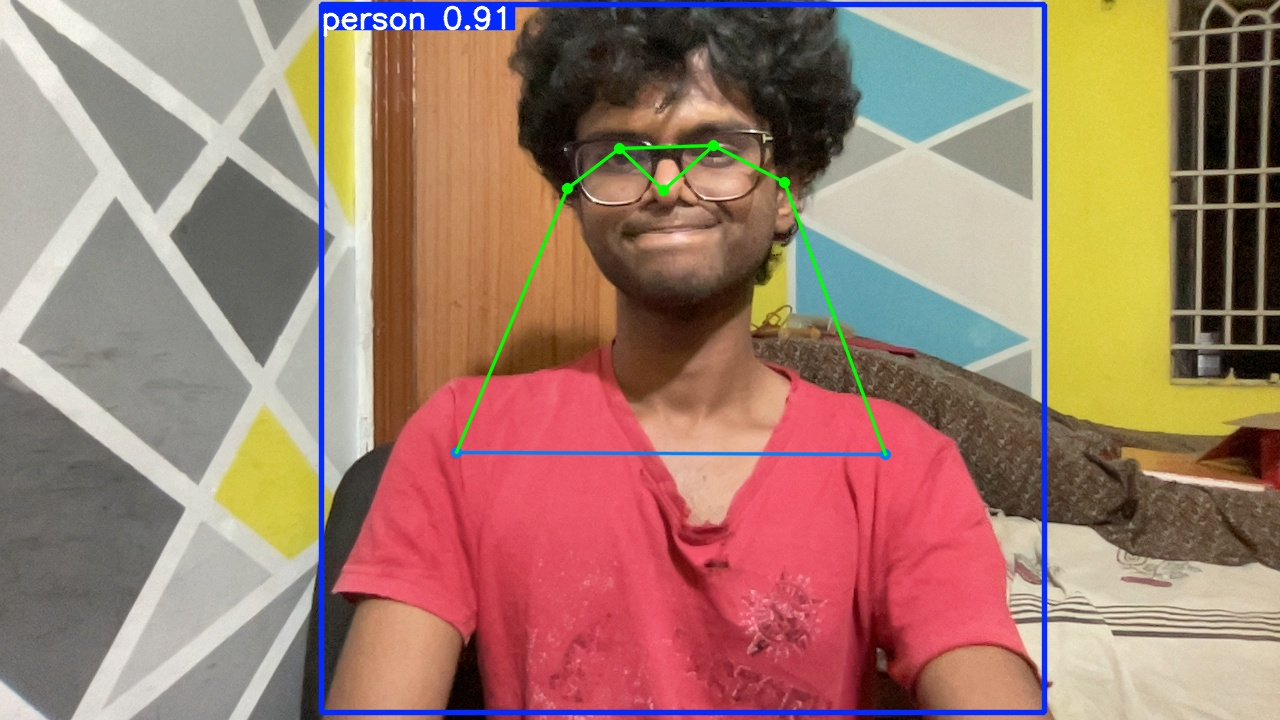

Escape key detected. Closing...
System safely shut down.


In [2]:
import cv2
from ultralytics import YOLO
from IPython.display import display, Image, clear_output

def run_pose_with_escape(model_name='yolov8n-pose.pt'):
    model = YOLO(model_name)
    cap = cv2.VideoCapture(0)
    
    # Create a small window just to listen for the keyboard
    cv2.namedWindow("KeyboardListener", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("KeyboardListener", 200, 50) 
    
    print("RUNNING: Click the small 'KeyboardListener' window and press ESC to stop.")
    
    try:
        while cap.isOpened():
            success, frame = cap.read()
            if not success: break

            # 1. Pose Detection
            results = model(frame, verbose=False)
            
            # 2. Visualize
            annotated_frame = results[0].plot()
            
            # 3. In-Cell Display
            _, buffer = cv2.imencode('.jpg', annotated_frame)
            clear_output(wait=True)
            display(Image(data=buffer.tobytes()))
            
            # 4. THE KEYBOARD ESCAPE LOGIC
            # 27 is the ASCII code for the Escape Key
            if cv2.waitKey(1) & 0xFF == 27:
                print("Escape key detected. Closing...")
                break
                
    except Exception as e:
        print(f"Error: {e}")
    finally:
        cap.release()
        cv2.destroyAllWindows() # This closes the listener window
        print("System safely shut down.")

run_pose_with_escape()